## Getting prompts for LLM evaluation

In [7]:
# Prompt 1. Evaluate the relevance of the generated answer to the original answer.
prompt1_template = """
You are an expert evaluator for a Retrieval-Augmented Generation (RAG) system.
Your task is to analyze the relevance of the generated answer compared to the original answer provided.
Based on the relevance and similarity of the generated answer to the original answer, you will classify
it as "NON_RELEVANT", "PARTLY_RELEVANT", or "RELEVANT".

Here is the data for evaluation:

Original Answer: {answer_orig}
Generated Question: {question}
Generated Answer: {answer_llm}

Please analyze the content and context of the generated answer in relation to the original
answer and provide your evaluation in parsable JSON without using code blocks:

{{
  "Relevance": "NON_RELEVANT" | "PARTLY_RELEVANT" | "RELEVANT",
  "Explanation": "[Provide a brief explanation for your evaluation]"
}}
""".strip()

# Prompt 2. Evaluate the relevance of the generated answer to the originalquestion.
prompt2_template = """
You are an expert evaluator for a Retrieval-Augmented Generation (RAG) system.
Your task is to analyze the relevance of the generated answer to the given question.
Based on the relevance of the generated answer, you will classify it
as "NON_RELEVANT", "PARTLY_RELEVANT", or "RELEVANT".

Here is the data for evaluation:

Question: {question}
Generated Answer: {answer_llm}

Please analyze the content and context of the generated answer in relation to the question
and provide your evaluation in parsable JSON without using code blocks:

{{
  "Relevance": "NON_RELEVANT" | "PARTLY_RELEVANT" | "RELEVANT",
  "Explanation": "[Provide a brief explanation for your evaluation]"
}}
""".strip()

## Case 1. Evaluate generated answer compared to question and original answer

In [15]:
import pandas as pd

url_prefix = url_prefix = 'https://raw.githubusercontent.com/DataTalksClub/llm-zoomcamp/main/03-evaluation/'
results_url = url_prefix + 'rag_evaluation/data/results-gpt4o-mini.csv'
df_gpt4o_mini = pd.read_csv(results_url)

df_smaple = df_gpt4o_mini.sample(n=100, random_state=1)

samples = df_smaple.to_dict(orient='records')

record = samples[0]

record

{'answer_llm': 'The syntax for using `precision_recall_fscore_support` in Python is as follows:\n\n```python\nfrom sklearn.metrics import precision_recall_fscore_support\nprecision, recall, fscore, support = precision_recall_fscore_support(y_val, y_val_pred, zero_division=0)\n```',
 'answer_orig': 'Scikit-learn offers another way: precision_recall_fscore_support\nExample:\nfrom sklearn.metrics import precision_recall_fscore_support\nprecision, recall, fscore, support = precision_recall_fscore_support(y_val, y_val_pred, zero_division=0)\n(Gopakumar Gopinathan)',
 'document': '403bbdd8',
 'question': 'What is the syntax for using precision_recall_fscore_support in Python?',
 'course': 'machine-learning-zoomcamp'}

In [16]:
prompt = prompt1_template.format(**record)

print(prompt)

You are an expert evaluator for a Retrieval-Augmented Generation (RAG) system.
Your task is to analyze the relevance of the generated answer compared to the original answer provided.
Based on the relevance and similarity of the generated answer to the original answer, you will classify
it as "NON_RELEVANT", "PARTLY_RELEVANT", or "RELEVANT".

Here is the data for evaluation:

Original Answer: Scikit-learn offers another way: precision_recall_fscore_support
Example:
from sklearn.metrics import precision_recall_fscore_support
precision, recall, fscore, support = precision_recall_fscore_support(y_val, y_val_pred, zero_division=0)
(Gopakumar Gopinathan)
Generated Question: What is the syntax for using precision_recall_fscore_support in Python?
Generated Answer: The syntax for using `precision_recall_fscore_support` in Python is as follows:

```python
from sklearn.metrics import precision_recall_fscore_support
precision, recall, fscore, support = precision_recall_fscore_support(y_val, y_val_

In [19]:
import json
from rag.llm.openai_client import OpenAIClient

client = OpenAIClient()

response = client.get_response(prompt = prompt, model = "gpt-4o-mini")

json.loads(response)

{'Relevance': 'RELEVANT',
 'Explanation': 'The generated answer directly addresses the question about the syntax for using `precision_recall_fscore_support` in Python and provides the exact code snippet from the original answer. It maintains the same context and content, making it fully relevant.'}

In [24]:
import tqdm
from rag.llm.openai_client import OpenAIClient

client = OpenAIClient()

judge_llm_answers = []

for record in tqdm.tqdm(samples):
    judge_llm_answer = client.get_response(prompt = prompt1_template.format(**record), model = "gpt-4o-mini")
    judge_llm_answers.append(judge_llm_answer)

judge_llm_answers

100%|██████████| 100/100 [03:02<00:00,  1.82s/it]


['{\n  "Relevance": "RELEVANT",\n  "Explanation": "The generated answer directly addresses the question about the syntax for using `precision_recall_fscore_support` in Python. It provides the exact code snippet mentioned in the original answer, making it highly relevant and accurate."\n}',
 '{\n  "Relevance": "RELEVANT",\n  "Explanation": "The generated answer directly addresses the question of how to modify scripts to avoid pickle errors when using waitress. It accurately summarizes the solution provided in the original answer, including the need to place the custom column transformer class in a separate module and import it in both the saving and loading scripts. The explanation aligns well with the context and details of the original answer."\n}',
 '{\n  "Relevance": "RELEVANT",\n  "Explanation": "The generated answer directly addresses the question about launching a container image in interactive mode and provides the exact command from the original answer, making it highly relevan

In [25]:
json_llm_judge_answers = []

for std_answer in judge_llm_answers:
    json_llm_judge_answers.append(json.loads(std_answer))

json_llm_judge_answers

[{'Relevance': 'RELEVANT',
  'Explanation': 'The generated answer directly addresses the question about the syntax for using `precision_recall_fscore_support` in Python. It provides the exact code snippet mentioned in the original answer, making it highly relevant and accurate.'},
 {'Relevance': 'RELEVANT',
  'Explanation': 'The generated answer directly addresses the question of how to modify scripts to avoid pickle errors when using waitress. It accurately summarizes the solution provided in the original answer, including the need to place the custom column transformer class in a separate module and import it in both the saving and loading scripts. The explanation aligns well with the context and details of the original answer.'},
 {'Relevance': 'RELEVANT',
  'Explanation': 'The generated answer directly addresses the question about launching a container image in interactive mode and provides the exact command from the original answer, making it highly relevant and accurate.'},
 {'Re

In [40]:
df_llm_judge_answers_1 = pd.DataFrame(json_llm_judge_answers)

df_llm_judge_answers_1

,Relevance,Explanation
0,RELEVANT,The generated answer directly addresses the qu...
1,RELEVANT,The generated answer directly addresses the qu...
2,RELEVANT,The generated answer directly addresses the qu...
3,RELEVANT,The generated answer directly addresses the qu...
4,NON_RELEVANT,The generated answer discusses a pip version e...
...,...,...
95,RELEVANT,The generated answer directly addresses the qu...
96,RELEVANT,The generated answer directly addresses the qu...
97,RELEVANT,The generated answer directly addresses the qu...
98,RELEVANT,The generated answer accurately addresses the ...


<Axes: title={'center': 'Relevance of LLM answers'}, ylabel='count'>

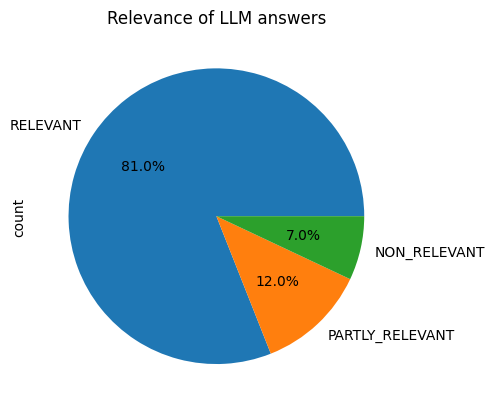

In [41]:
relevance_1 = df_llm_judge_answers_1.Relevance.value_counts()

relevance_1.plot(kind='pie', autopct='%1.1f%%', title='Relevance of LLM answers')

In [42]:
df_llm_judge_answers_1[df_llm_judge_answers_1.Relevance == "NON_RELEVANT"]

,Relevance,Explanation
4,NON_RELEVANT,The generated answer discusses a pip version e...
11,NON_RELEVANT,The generated answer addresses a different iss...
27,NON_RELEVANT,The generated answer incorrectly states that t...
41,NON_RELEVANT,The generated answer addresses a completely di...
87,NON_RELEVANT,The generated answer addresses a different asp...
90,NON_RELEVANT,The generated answer addresses a different que...
93,NON_RELEVANT,The generated answer does not address the cont...


In [43]:
err_rec_example = samples[4]
err_rec_example

{'answer_llm': "The cause of the pip version error in this week's serverless deep learning section could be a version conflict in Scikit-Learn. Specifically, if you are using a different version than what was used during the model training, it can lead to warnings and potential breaking code or invalid results. To resolve this, make sure to use the same version of Scikit-Learn that was used for training the model. For instance, if you trained with version 1.1.1, you should use that same version in your virtual environment.",
 'answer_orig': 'When running docker build -t dino-dragon-model it returns the above error\nThe most common source of this error in this week is because Alex video shows a version of the wheel with python 8, we need to find a wheel with the version that we are working on. In this case python 9. Another common error is to copy the link, this will also produce the same error, we need to download the raw format:\nhttps://github.com/alexeygrigorev/tflite-aws-lambda/raw

## Case 2. Evaluate the generated answer compared to the question

In [39]:
prompt = prompt2_template.format(**record)

print(prompt)

You are an expert evaluator for a Retrieval-Augmented Generation (RAG) system.
Your task is to analyze the relevance of the generated answer to the given question.
Based on the relevance of the generated answer, you will classify it
as "NON_RELEVANT", "PARTLY_RELEVANT", or "RELEVANT".

Here is the data for evaluation:

Question: What kind of error occurs when running 'eb local run --port 9696'?
Generated Answer: When running the command 'eb local run --port 9696', a NotSupportedError occurs. The error message states: "ERROR: NotSupportedError - You can use 'eb local' only with preconfigured, generic and multicontainer Docker platforms."

Please analyze the content and context of the generated answer in relation to the question
and provide your evaluation in parsable JSON without using code blocks:

{
  "Relevance": "NON_RELEVANT" | "PARTLY_RELEVANT" | "RELEVANT",
  "Explanation": "[Provide a brief explanation for your evaluation]"
}


In [44]:
import tqdm
from rag.llm.openai_client import OpenAIClient

client = OpenAIClient()

judge_llm_answers_2 = []

for record in tqdm.tqdm(samples):
    judge_llm_answer_2 = client.get_response(prompt = prompt2_template.format(**record), model = "gpt-4o-mini")
    judge_llm_answers_2.append(judge_llm_answer_2)

judge_llm_answers_2

100%|██████████| 100/100 [03:00<00:00,  1.80s/it]


['{\n  "Relevance": "RELEVANT",\n  "Explanation": "The generated answer directly addresses the question by providing the correct syntax for using the `precision_recall_fscore_support` function in Python, including an example of how to import it and use it with parameters."\n}',
 '{\n  "Relevance": "RELEVANT",\n  "Explanation": "The generated answer directly addresses the question about modifying scripts to avoid pickle errors when using waitress. It provides a specific solution by suggesting the separation of the custom column transformer class into a different module and explains how this approach helps prevent the errors, which is exactly what the question is asking for."\n}',
 '{\n  "Relevance": "RELEVANT",\n  "Explanation": "The generated answer directly addresses the question by providing the correct command to launch a container image in interactive mode, specifically mentioning the use of \'docker run -it\' which is accurate and relevant to the query."\n}',
 '{\n  "Relevance": "

In [45]:
json_llm_judge_answers_2 = []

for std_answer in judge_llm_answers_2:
    json_llm_judge_answers_2.append(json.loads(std_answer))

json_llm_judge_answers_2

[{'Relevance': 'RELEVANT',
  'Explanation': 'The generated answer directly addresses the question by providing the correct syntax for using the `precision_recall_fscore_support` function in Python, including an example of how to import it and use it with parameters.'},
 {'Relevance': 'RELEVANT',
  'Explanation': 'The generated answer directly addresses the question about modifying scripts to avoid pickle errors when using waitress. It provides a specific solution by suggesting the separation of the custom column transformer class into a different module and explains how this approach helps prevent the errors, which is exactly what the question is asking for.'},
 {'Relevance': 'RELEVANT',
  'Explanation': "The generated answer directly addresses the question by providing the correct command to launch a container image in interactive mode, specifically mentioning the use of 'docker run -it' which is accurate and relevant to the query."},
 {'Relevance': 'RELEVANT',
  'Explanation': 'The g

In [46]:
df_llm_judge_answers_2 = pd.DataFrame(json_llm_judge_answers_2)

df_llm_judge_answers_2

,Relevance,Explanation
0,RELEVANT,The generated answer directly addresses the qu...
1,RELEVANT,The generated answer directly addresses the qu...
2,RELEVANT,The generated answer directly addresses the qu...
3,RELEVANT,The generated answer directly addresses the qu...
4,PARTLY_RELEVANT,The generated answer discusses a potential cau...
...,...,...
95,RELEVANT,The generated answer provides clear and specif...
96,RELEVANT,The generated answer directly addresses the qu...
97,PARTLY_RELEVANT,The generated answer provides a specific numbe...
98,PARTLY_RELEVANT,The generated answer addresses the question ab...


<Axes: title={'center': 'Relevance of LLM answers'}, ylabel='count'>

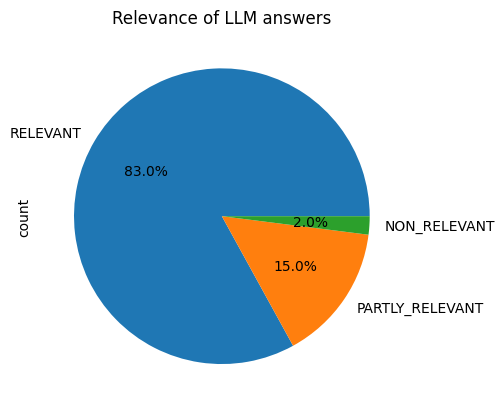

In [47]:
relevance = df_llm_judge_answers_2.Relevance.value_counts()

relevance.plot(kind='pie', autopct='%1.1f%%', title='Relevance of LLM answers')

In [51]:
df_llm_judge_answers_2[df_llm_judge_answers_2.Relevance == "NON_RELEVANT"].to_dict(orient='records')

[{'Relevance': 'NON_RELEVANT',
  'Explanation': 'The generated answer does not provide any relevant information or commands related to starting the Docker daemon on Linux. It merely states the lack of context without addressing the question directly.'},
 {'Relevance': 'NON_RELEVANT',
  'Explanation': 'The generated answer does not address the question about the existence of a YouTube video on Evaluation Metrics for Classification. Instead, it discusses methods for obtaining classification metrics without mentioning any video resources, making it irrelevant to the specific inquiry.'}]

In [50]:
err_rec_example_2 = samples[49]
err_rec_example_2

{'answer_llm': 'Based on the provided context, there is no mention of a YouTube video covering Evaluation Metrics for Classification. The information provided focuses on methods to obtain classification metrics and visualizations using libraries such as scikit-learn and Yellowbrick, but does not reference any video resources.',
 'answer_orig': 'Week 4 HW: https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/cohorts/2023/04-evaluation/homework.md\nAll HWs: https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/cohorts/2023/\nEvaluation Matrix: https://docs.google.com/spreadsheets/d/e/2PACX-1vQCwqAtkjl07MTW-SxWUK9GUvMQ3Pv_fF8UadcuIYLgHa0PlNu9BRWtfLgivI8xSCncQs82HDwGXSm3/pubhtml\nGitHub for theory: https://github.com/alexeygrigorev/mlbookcamp-code/tree/master/course-zoomcamp\nYouTube Link: 4.X --- https://www.youtube.com/watch?v=gmg5jw1bM8A&list=PL3MmuxUbc_hIhxl5Ji8t4O6lPAOpHaCLR&index=40\nSci-Kit Learn on Evaluation:\nhttps://scikit-learn.org/stable/mode